# Load packages

In [1]:
# Import packages
from neuromaps import transforms, nulls, datasets, plotting, images, resampling, stats, parcellate; # import neuromaps and its submodules
from neuromaps.datasets import fetch_fsaverage, fetch_fslr;
from surfplot import Plot; # this package will be used to plot the data on a brain surface
from nilearn import plotting as nplot; # this package will be used to plot the data on a brain volume
import nibabel as nib;
from nibabel import freesurfer
# from nilearn.datasets import fetch_atlas_surf_destrieux, load_fsaverage, load_fsaverage_data
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
from IPython.display import HTML
import os
os.environ["PATH"] += ":/Users/guofanhua/Desktop/gfh/tools/workbench/bin_macosx64"
import pandas as pd
from scipy.stats import zscore
from eigenstrapping import SurfaceEigenstrapping



# Data load and preprocess

## load surface data 

In [2]:
# Fetch surface data of fsaverage we wil use for plotting with 10k vertices
surfaces_fsaverage_10 = fetch_fsaverage(density='10k') 
lh_fsaverage_10, rh_fsaverage_10 = surfaces_fsaverage_10['inflated'] # there are many types of surfaces, we will use inflated surface for easy visualization of gyri and sulci

# # Fetch surface data of fsaverage we wil use for plotting with 41k vertices
# surfaces_fsaverage_41 = fetch_fsaverage(density='41k') 
# lh_fsaverage_41, rh_fsaverage_41 = surfaces_fsaverage_41['inflated'] # there are many types of surfaces, we will use inflated surface for easy visualization of gyri and sulci

## load parcellation data

In [3]:
# Get HCP-MMP1.0 atlas
def prep_hcp_mmp_parcellation(annot_left_path , annot_right_path):
    '''Takes the path to the right and left hemisphere annotation files
    and loads everything.
    '''
    hcp_mmp = {}
    annot_left = freesurfer.read_annot(annot_left_path)
    annot_right = freesurfer.read_annot(annot_right_path)
    labels=annot_left[2]
    map_left=annot_left[0]
    map_right=annot_right[0]

    hcp_mmp['labels'] = labels
    
    hcp_mmp['map_left'] = map_left
    hcp_mmp['map_right'] = map_right

    print(f"Keys available: {sorted(hcp_mmp)}")
    print(f"Number of vertices in each hemisphere: {len(hcp_mmp['map_left'])} , {len(hcp_mmp['map_right'])}")
    print(f"Number of labels: {len(hcp_mmp['labels'])}")

    return hcp_mmp

# sample use
annot_left_path = "/Users/guofanhua/Desktop/gfh/work/StandardBrainTemplateAndAtlas/AllenBrain/microarray/atlas/fsa5_lh_glasser_360.annot"
annot_right_path = "/Users/guofanhua/Desktop/gfh/work/StandardBrainTemplateAndAtlas/AllenBrain/microarray/atlas/fsa5_rh_glasser_360.annot"
hcp_mmp = prep_hcp_mmp_parcellation(annot_left_path , annot_right_path)

labels = [label.decode() for label in hcp_mmp['labels']]
parc_left = images.construct_shape_gii(hcp_mmp['map_left'], labels=labels, intent='NIFTI_INTENT_LABEL')
parc_right = images.construct_shape_gii(hcp_mmp['map_right'], labels=labels, intent='NIFTI_INTENT_LABEL')
parcellation = images.relabel_gifti((parc_left, parc_right), background=['medialwall'])
parcellation = transforms.fsaverage_to_fsaverage(parcellation, target_density='10k', method='nearest')
print(parcellation)
hcp_mmp_parc = parcellate.Parcellater(parcellation=parcellation, space='fsaverage').fit() # create the parcellator for the HCP_MMP atlas

# # plot the hcp_mmp1_0 atlas resampled on the fsaverage brain
# p = Plot(surf_lh=lh_fsaverage_10, surf_rh=rh_fsaverage_10)
# p.add_layer(images.load_data(parcellation), cmap='viridis')
# fig = p.build()
# fig.axes[0].set_title('HCP-MMP', pad=-3)
# fig.show()


Keys available: ['labels', 'map_left', 'map_right']
Number of vertices in each hemisphere: 10242 , 10242
Number of labels: 181
(<nibabel.gifti.gifti.GiftiImage object at 0x1ac096710>, <nibabel.gifti.gifti.GiftiImage object at 0x1ac0969b0>)


# batch for null compute

## 1）variogram-null

In [6]:
# set basic info for the scan data you want to analyze
FilePath = '/Users/guofanhua/Desktop/gfh/work/experiment/ASL_Mesoscopic2025/code/Data/group/'
UniOrBil = 'bil'  # bil or uni
numlayers = '6'
FileNames = ['CBF_Mean_PScs']
# FileNames = ['CBF_Mean_PScs', 'CBF_PC1_Val',
#              'CBF_Mean_Val',
#              'T1vCBF_Mean_PScs', 'T1vBB_Mean_PScs',
#              'T1wCBF_Mean_PScs', 'T1wBB_Mean_PScs',
#              'CBF_Mean_PScs_uncorr']

for FileName in FileNames:
    LabelName = FileName + '_L' + numlayers
    data_path = FilePath + LabelName + '_' + UniOrBil + '.1D'
    save_path = FilePath + LabelName + '_' + UniOrBil + '_variogram.1D'
    
    data_parc = np.loadtxt(data_path, dtype=np.float32)
    
    data_parc_null = nulls.burt2020(data_parc, 
                        atlas='fsaverage', 
                        density='10k', 
                        n_perm=20000, 
                        seed=1234, 
                        parcellation=parcellation,
                        n_proc = 4
                        )
    print(data_parc_null.shape)

    np.savetxt(save_path, data_parc_null, fmt='%.6f')





(360, 20000)


retest data

In [5]:
# compute for retest
# set basic info for the scan data you want to analyze
FilePath = '/Users/guofanhua/Desktop/gfh/work/experiment/ASL_Mesoscopic2025/code/Data/group/'
UniOrBil = 'uni'  # bil or uni
FileNames = ['retest_Mean_PScs']

for FileName in FileNames:
    LabelName = FileName
    data_path = FilePath + FileName + '_' +UniOrBil + '.1D'
    save_path = FilePath + FileName + '_' +UniOrBil + '_variogram.1D'
    
    data_parc = np.loadtxt(data_path, dtype=np.float32)
    
    data_parc_null = nulls.burt2020(data_parc, 
                        atlas='fsaverage', 
                        density='10k', 
                        n_perm=20000, 
                        seed=1234, 
                        parcellation=parcellation,
                        n_proc = 4
                        )
    print(data_parc_null.shape)

    np.savetxt(save_path, data_parc_null, fmt='%.6f')




(360, 20000)


random resample

In [7]:
# compute for random-subjects
# set basic info for the scan data you want to analyze
FilePath = '/Users/guofanhua/Desktop/gfh/work/experiment/ASL_Mesoscopic2025/code/Data/group/verification/'
UniOrBil = 'uni'  # bil or uni
FileNames1 = ['5','10','15','20']
FileNames2 = ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20']

for FileName1 in FileNames1:
    print('start ' + FileName1 + '\n')
    for FileName2 in FileNames2:
        data_path = FilePath + 'CCSI_' + FileName1 + '_' + FileName2 + '_' +UniOrBil + '.1D'
        save_path = FilePath + 'CCSI_' + FileName1 + '_' + FileName2 + '_' +UniOrBil + '_variogram.1D'
        
        data_parc = np.loadtxt(data_path, dtype=np.float32)
        
        data_parc_null = nulls.burt2020(data_parc, 
                            atlas='fsaverage', 
                            density='10k', 
                            n_perm=20000, 
                            seed=1234, 
                            parcellation=parcellation,
                            n_proc = 4
                            )
        # print(data_parc_null.shape)
        if FileName2 == '11':
            print('finish 10 times')

        np.savetxt(save_path, data_parc_null, fmt='%.6f')


start 5

finish 10 times
start 10

finish 10 times
start 15

finish 10 times
start 20

finish 10 times


split half

In [6]:
# compute for split-half-subjects
# set basic info for the scan data you want to analyze
FilePath = '/Users/guofanhua/Desktop/gfh/work/experiment/ASL_Mesoscopic2025/code/Data/group/SplitHalf/'
UniOrBil = 'uni'  # bil or uni
FileNames1 = ['1','2']
FileNames2 = ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20']

for FileName1 in FileNames1:
    print('start ' + FileName1 + '\n')
    for FileName2 in FileNames2:
        data_path = FilePath + 'CCSI' + FileName1 + '_' + FileName2 + '_' +UniOrBil + '.1D'
        save_path = FilePath + 'CCSI' + FileName1 + '_' + FileName2 + '_' +UniOrBil + '_variogram.1D'
        
        data_parc = np.loadtxt(data_path, dtype=np.float32)
        
        data_parc_null = nulls.burt2020(data_parc, 
                            atlas='fsaverage', 
                            density='10k', 
                            n_perm=20000, 
                            seed=1234, 
                            parcellation=parcellation,
                            n_proc = 4
                            )
        # print(data_parc_null.shape)
        if FileName2 == '11':
            print('finish 10 times')

        np.savetxt(save_path, data_parc_null, fmt='%.6f')


start 1

finish 10 times
start 2

finish 10 times


## 2）spin-null

In [4]:
# set basic info for the scan data you want to analyze
FilePath = '/Users/guofanhua/Desktop/gfh/work/experiment/ASL_Mesoscopic2025/code/Data/group/'
UniOrBil = 'bil'  # bil or uni
numlayers = '12'
FileNames = ['CBF_Mean_PScs']
# FileNames = ['CBF_Mean_PScs', 'CBF_PC1_Val',
#             'CBF_PC2_Val', 'CBF_PC3_Val',
#             'CBF_PC1_Val_Layer1',
#             'CBF_PC1_Val_Layer2', 'CBF_PC1_Val_Layer3',
#             'CBF_PC1_Val_Layer4', 'CBF_PC1_Val_Layer5',
#             'CBF_PC1_Val_Layer6']
seeds = [1234, 2432, 4312, 9834, 4324, 7458, 7548, 2398, 4869, 9745]

for FileName in FileNames:
    LabelName = FileName + '_L' + numlayers
    data_path = FilePath + LabelName + '_' + UniOrBil + '.1D'
    save_path = FilePath + LabelName + '_' + UniOrBil + '_spin.1D'
    
    data_parc = np.loadtxt(data_path, dtype=np.float32)
    
    data_parc_null = np.zeros((360,20000))
    for i in range(len(seeds)):
        print(f'start {i+1}')
        tmp = nulls.cornblath(data_parc, 
                            atlas='fsaverage', 
                            density='10k', 
                            n_perm=2000, 
                            seed=seeds[i], 
                            parcellation=parcellation
                            )
        data_parc_null[:,2000*i:2000*i+2000] = tmp
    print(data_parc_null.shape)

    np.savetxt(save_path, data_parc_null, fmt='%.6f')



start 1
start 2
start 3
start 4
start 5
start 6
start 7
start 8
start 9
start 10
(360, 20000)


## 3）eigenstrapping

In [5]:
# set basic info for the scan data you want to analyze
FilePath = '/Users/guofanhua/Desktop/gfh/work/experiment/ASL_Mesoscopic2025/code/Data/group/'
UniOrBil = 'bil'  # bil or uni
numlayers = '12'
FileNames = ['CBF_Mean_PScs']
# FileNames = ['CBF_Mean_PScs', 'CBF_PC1_Val',
#             'CBF_PC2_Val', 'CBF_PC3_Val',
#             'CBF_PC1_Val_Layer1',
#             'CBF_PC1_Val_Layer2', 'CBF_PC1_Val_Layer3',
#             'CBF_PC1_Val_Layer4', 'CBF_PC1_Val_Layer5',
#             'CBF_PC1_Val_Layer6']
seeds = [1234, 2432, 4312, 9834, 4324, 7458, 7548, 2398, 4869, 9745]
# seeds = [1234]

for FileName in FileNames:
    LabelName = FileName + '_L' + numlayers
    data_path = FilePath + LabelName + '_' + UniOrBil + '.1D'
    save_path = FilePath + LabelName + '_' + UniOrBil + '_eigenstrapping.1D'
    
    data_parc = np.loadtxt(data_path, dtype=np.float32)
    data_vertex = images.load_data(hcp_mmp_parc.inverse_transform(data_parc))
    lh_data = data_vertex[:10242]
    rh_data = data_vertex[10242:]

    fsavg = fetch_fsaverage(density='10k')
    lh_surf = str(fsavg['pial'][0])
    rh_surf = str(fsavg['pial'][1])

    data_parc_null = np.zeros((360,2000*len(seeds)))
    for i in range(len(seeds)):
        print(f'start {i+1}')
        eig_lh = SurfaceEigenstrapping(
            lh_data,
            surface=lh_surf,
            num_modes=200, seed=seeds[i], add_res=False
        )
        eig_rh = SurfaceEigenstrapping(
            rh_data,
            surface=rh_surf,
            num_modes=200, seed=seeds[i], add_res=False
        )
        surr_lh = eig_lh(n=2000)
        surr_rh = eig_rh(n=2000)
        surr = np.concatenate((surr_lh.T, surr_rh.T),axis=0)
        for k in range(2000):
            data_parc_null[:,k+2000*i] = hcp_mmp_parc.transform(data=surr[:,k], space='fsaverage') # parcellate the neurosynth data

    print(data_parc_null.shape)

    np.savetxt(save_path, data_parc_null, fmt='%.6f')


start 1
Computing eigenmodes on surface using N=200 modes


/Users/guofanhua/opt/anaconda3/envs/ImagingGenetics/lib/python3.10/site-packages/eigenstrapping/geometry.py:910: UserWarning: Number of selected points=9403. Expected 9402.This may be due to the topology after selection.
  warnings.warn('Number of selected {}={}. Expected {}.'


IMPORTANT: EIGENMODES MUST BE TRUNCATED AT FIRST NON-ZERO MODE FOR THIS FUNCTION TO WORK
Computing eigenmodes on surface using N=200 modes


/Users/guofanhua/opt/anaconda3/envs/ImagingGenetics/lib/python3.10/site-packages/eigenstrapping/geometry.py:910: UserWarning: Number of selected points=9380. Expected 9379.This may be due to the topology after selection.
  warnings.warn('Number of selected {}={}. Expected {}.'


IMPORTANT: EIGENMODES MUST BE TRUNCATED AT FIRST NON-ZERO MODE FOR THIS FUNCTION TO WORK
start 2
Computing eigenmodes on surface using N=200 modes
IMPORTANT: EIGENMODES MUST BE TRUNCATED AT FIRST NON-ZERO MODE FOR THIS FUNCTION TO WORK
Computing eigenmodes on surface using N=200 modes
IMPORTANT: EIGENMODES MUST BE TRUNCATED AT FIRST NON-ZERO MODE FOR THIS FUNCTION TO WORK
start 3
Computing eigenmodes on surface using N=200 modes
IMPORTANT: EIGENMODES MUST BE TRUNCATED AT FIRST NON-ZERO MODE FOR THIS FUNCTION TO WORK
Computing eigenmodes on surface using N=200 modes
IMPORTANT: EIGENMODES MUST BE TRUNCATED AT FIRST NON-ZERO MODE FOR THIS FUNCTION TO WORK
start 4
Computing eigenmodes on surface using N=200 modes
IMPORTANT: EIGENMODES MUST BE TRUNCATED AT FIRST NON-ZERO MODE FOR THIS FUNCTION TO WORK
Computing eigenmodes on surface using N=200 modes
IMPORTANT: EIGENMODES MUST BE TRUNCATED AT FIRST NON-ZERO MODE FOR THIS FUNCTION TO WORK
start 5
Computing eigenmodes on surface using N=200 m

In [90]:
# surr_lh = eig_lh(n=10)

for i in range(10):
    x = lh_data
    y = surr_lh[i]
    
    mask = ~np.isnan(x) & ~np.isnan(y)
    corr = np.corrcoef(x[mask], y[mask])[0,1]
    print(corr)

0.9999999999999989
0.9999999999999989
0.999999999999999
0.9999999999999994
0.999999999999999
0.9999999999999987
0.9999999999999997
0.9999999999999989
0.9999999999999984
0.9999999999999979


# test the variogram function of data and null map

get the distance-matrix

In [6]:
# get the distance-matrix
atlas = 'fsaverage'
density = '10k'
n_proc = 4

for n, (hemi, parc) in enumerate(zip(('L', 'R'), parcellation)):
    if hemi == 'R':
        distmat_R = nulls.nulls._get_distmat(hemi, atlas=atlas, density=density,
                            parcellation=parc, n_proc=n_proc)
    else:
        distmat_L = nulls.nulls._get_distmat(hemi, atlas=atlas, density=density,
                            parcellation=parc, n_proc=n_proc)


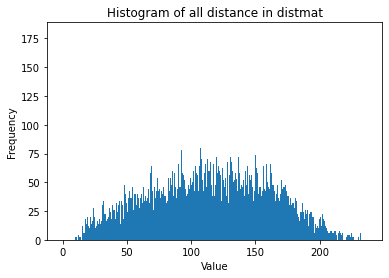

In [5]:
# plot the hist

# values = distmat_L.flatten(), 
values = distmat_R.flatten()

# 2️⃣ 画直方图
plt.figure()
plt.hist(values, bins=1000)  # bins 可以自己调整

# 设置坐标轴范围
# plt.xlim(0, 1)
# plt.ylim(0, 50000)

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of all distance in distmat")
plt.show()


read the data

In [25]:
FileName = 'CBF_Mean_PScs_L12'   # CBF_Mean_PScs_L12  CBF_PC1_Val CBF_Mean_PScs_uncorr_L12
FilePath = '/Users/guofanhua/Desktop/gfh/work/experiment/ASL_Mesoscopic2025/code/Data/group/'
UniOrBil = 'bil'  # bil or uni

data_path = FilePath + FileName + '_' +UniOrBil + '.1D'
realData = np.loadtxt(data_path) 

null_path = FilePath + FileName + '_' +UniOrBil + '_variogram.1D'  # _eigenstrapping _variogram _spin
varioData = np.loadtxt(null_path) 

null_path = FilePath + FileName + '_' +UniOrBil + '_spin.1D'  # _eigenstrapping _variogram _spin
spinData = np.loadtxt(null_path) 

null_path = FilePath + FileName + '_' +UniOrBil + '_eigenstrapping.1D'  # _eigenstrapping _variogram _spin
eigenData = np.loadtxt(null_path) 


compute variogram function curve and plot it

In [26]:
def compute_variogram_function_curve(Val_L, Val_R, dismat_L = distmat_L, dismat_R = distmat_R, step=25, last_TP=200):
    Valmat_L = np.abs(Val_L[:, None] - Val_L[None, :])
    Valmat_R = np.abs(Val_R[:, None] - Val_R[None, :])
    VL = Valmat_L.flatten()
    VR = Valmat_R.flatten()
    DL = dismat_L.flatten()
    DR = dismat_R.flatten()
    V = np.concatenate((VL, VR))
    D = np.concatenate((DL, DR))
    # print("V nan ratio:", np.mean(np.isnan(V)))
    n_bin = last_TP // step
    bin_std = np.zeros(n_bin+1)
    for i in range(n_bin):
        bin_std[i] = np.nanstd(V[(D > i*step) & (D <= (i+1)*step)],axis=0)
    bin_std[n_bin] = np.nanstd(V[D > last_TP],axis=0)
    return bin_std


# get the real variogram_function_curve
tmpData = realData
tmpData = zscore(tmpData, nan_policy='omit')
real_VFC = compute_variogram_function_curve(tmpData[0:180], tmpData[180:360], distmat_L, distmat_R)

# get the null variogram_function_curve
nROIs, nSurrs = varioData.shape
# nSurrs = 1
vario_VFC = np.zeros((real_VFC.shape[0], nSurrs))
for i in range(nSurrs):
    tmpData = varioData[:,i]
    tmpData = zscore(tmpData, nan_policy='omit')
    vario_VFC[:,i] = compute_variogram_function_curve(tmpData[0:180], tmpData[180:360], distmat_L, distmat_R)

# get the null spin_function_curve
nROIs, nSurrs = spinData.shape
# nSurrs = 1
spin_VFC = np.zeros((real_VFC.shape[0], nSurrs))
for i in range(nSurrs):
    tmpData = spinData[:,i]
    tmpData = zscore(tmpData, nan_policy='omit')
    spin_VFC[:,i] = compute_variogram_function_curve(tmpData[0:180], tmpData[180:360], distmat_L, distmat_R)

# get the null eigenstrapping_function_curve
nROIs, nSurrs = eigenData.shape
# nSurrs = 1
eigen_VFC = np.zeros((real_VFC.shape[0], nSurrs))
for i in range(nSurrs):
    tmpData = eigenData[:,i]
    tmpData = zscore(tmpData, nan_policy='omit')
    eigen_VFC[:,i] = compute_variogram_function_curve(tmpData[0:180], tmpData[180:360], distmat_L, distmat_R)



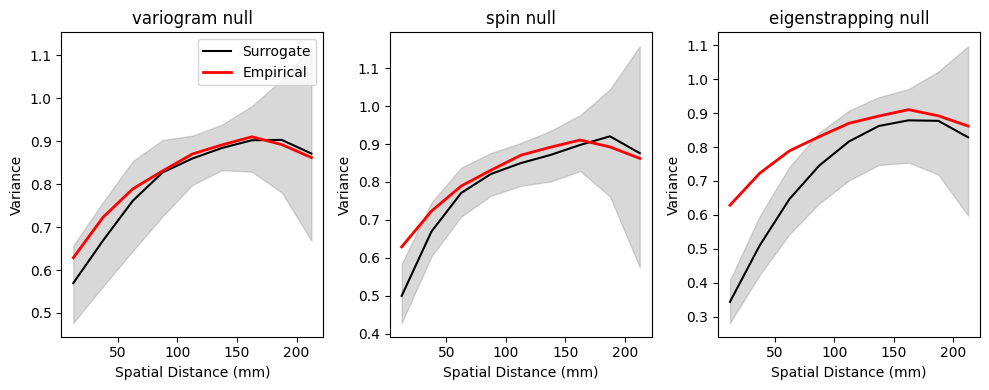

In [46]:
# x 轴
x = np.arange(len(real_VFC))
x = x*25+12.5

# plotting
fig, ax = plt.subplots(1, 3, figsize=(10,4))

# variogram
ima = 0
null_VFC = vario_VFC
null_mean = np.nanmean(null_VFC, axis=1)
lower = np.percentile(null_VFC, 2.5, axis=1)
upper = np.percentile(null_VFC, 97.5, axis=1)
ax[ima].fill_between(x, lower, upper, color='gray', alpha=0.3)
ax[ima].plot(x, null_mean, color='black', label='Surrogate')
ax[ima].plot(x, real_VFC, color='red', linewidth=2, label='Empirical')
ax[ima].set_xlabel("Spatial Distance (mm)")
ax[ima].set_ylabel("Variance")
ax[ima].legend()
ax[ima].set_title('variogram null')
# ax[0].show(f)
# set_axis_off

# f = plt.imread(f'{group_dir}/maps/{tmp_moda}_inner_young_group.png')
# ax[0].imshow(f)
# ax[0].set_axis_off()
# ax[0].set_anchor("NW")
# ax[0].set_title(f'young group inner surface {tmp_moda} PDD map')


# spin
ima = 1
null_VFC = spin_VFC
null_mean = np.nanmean(null_VFC, axis=1)
lower = np.percentile(null_VFC, 2.5, axis=1)
upper = np.percentile(null_VFC, 97.5, axis=1)
ax[ima].fill_between(x, lower, upper, color='gray', alpha=0.3)
ax[ima].plot(x, null_mean, color='black', label='Surrogate')
ax[ima].plot(x, real_VFC, color='red', linewidth=2, label='Empirical')
ax[ima].set_xlabel("Spatial Distance (mm)")
ax[ima].set_ylabel("Variance")
# ax[ima].legend()
ax[ima].set_title('spin null')


# eigenstrapping
ima = 2
null_VFC = eigen_VFC
null_mean = np.nanmean(null_VFC, axis=1)
lower = np.percentile(null_VFC, 2.5, axis=1)
upper = np.percentile(null_VFC, 97.5, axis=1)
ax[ima].fill_between(x, lower, upper, color='gray', alpha=0.3)
ax[ima].plot(x, null_mean, color='black', label='Surrogate')
ax[ima].plot(x, real_VFC, color='red', linewidth=2, label='Empirical')
ax[ima].set_xlabel("Spatial Distance (mm)")
ax[ima].set_ylabel("Variance")
# ax[ima].legend()
ax[ima].set_title('eigenstrapping null')


plt.tight_layout()


quantitative index (r/R2/RMSE)

In [45]:
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, r2_score

emp_var = real_VFC

# variogram
null_mean = vario_VFC.mean(axis=1)
# 1. 确保数据中没有 NaN (如果有，需要剔除)
mask = ~np.isnan(emp_var) & ~np.isnan(null_mean)
y_true = emp_var[mask]
y_pred = null_mean[mask]
# 2. 计算各项指标
corr, _ = pearsonr(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
print(f"Pearson correlation (r): {corr:.4f}")
print(f"Coefficient of determination (R2): {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# spin
null_mean = spin_VFC.mean(axis=1)
# 1. 确保数据中没有 NaN (如果有，需要剔除)
mask = ~np.isnan(emp_var) & ~np.isnan(null_mean)
y_true = emp_var[mask]
y_pred = null_mean[mask]
# 2. 计算各项指标
corr, _ = pearsonr(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
print(f"Pearson correlation (r): {corr:.4f}")
print(f"Coefficient of determination (R2): {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# eigenstrapping
null_mean = eigen_VFC.mean(axis=1)
# 1. 确保数据中没有 NaN (如果有，需要剔除)
mask = ~np.isnan(emp_var) & ~np.isnan(null_mean)
y_true = emp_var[mask]
y_pred = null_mean[mask]
# 2. 计算各项指标
corr, _ = pearsonr(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
print(f"Pearson correlation (r): {corr:.4f}")
print(f"Coefficient of determination (R2): {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

Pearson correlation (r): 0.9956
Coefficient of determination (R2): 0.8911
RMSE: 0.0291
Pearson correlation (r): 0.9871
Coefficient of determination (R2): 0.6845
RMSE: 0.0495
Pearson correlation (r): 0.9970
Coefficient of determination (R2): -1.2910
RMSE: 0.1334


eigenstrapping different model number compare

In [61]:
FileName = 'CBF_Mean_PScs_L12'   # CBF_Mean_PScs_L12  CBF_PC1_Val CBF_Mean_PScs_uncorr_L12
FilePath = '/Users/guofanhua/Desktop/gfh/work/experiment/ASL_Mesoscopic2025/code/Data/group/'
UniOrBil = 'bil'  # bil or uni


# get the real variogram_function_curve
data_path = FilePath + 'CBF_Mean_PScs_uncorr_L12' + '_' +UniOrBil + '.1D'
tmpData = np.loadtxt(data_path) 
tmpData = zscore(tmpData, nan_policy='omit')
real_VFC = compute_variogram_function_curve(tmpData[0:180], tmpData[180:360], distmat_L, distmat_R)


# get the multiple eigenstrapping variogram_function_curve
numbers = ['15', '25', '50', '100', '150', '200', '300', '700', '3000']
nVFC = real_VFC.shape
mean_eigen_VFC = np.zeros((nVFC[0],len(numbers)))
for n in range(len(numbers)):
    num = numbers[n]
    null_path = FilePath + FileName + '_' +UniOrBil + '_eigenstrapping' + num + '.1D'  # _eigenstrapping _variogram _spin
    eigenData = np.loadtxt(null_path) 

    nROIs, nSurrs = eigenData.shape
    # nSurrs = 1
    eigen_VFC = np.zeros((real_VFC.shape[0], nSurrs))
    for i in range(nSurrs):
        tmpData = eigenData[:,i]
        tmpData = zscore(tmpData, nan_policy='omit')
        eigen_VFC[:,i] = compute_variogram_function_curve(tmpData[0:180], tmpData[180:360], distmat_L, distmat_R)
    mean_eigen_VFC[:,n] = eigen_VFC.mean(axis=1)



Text(0.5, 1.0, 'different eigenstrapping modes number')

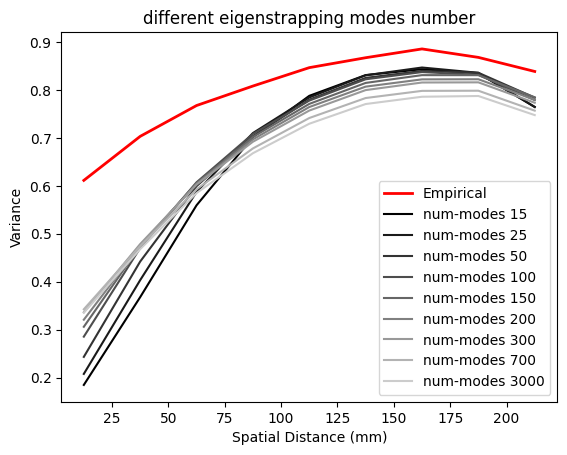

In [62]:
# x 轴
x = np.arange(len(real_VFC))
x = x*25+12.5

# plotting
fig = plt.plot(figsize=(10,4))

# variogram
ima = 0
null_VFC = mean_eigen_VFC
plt.plot(x, real_VFC, color=(1,0,0), linewidth=2, label='Empirical')

for i in range(len(numbers)):
    plt.plot(x, null_VFC[:,i], color=(i/10,i/10,i/10), label='num-modes '+numbers[i])


plt.xlabel("Spatial Distance (mm)")
plt.ylabel("Variance")
plt.legend()
plt.title('different eigenstrapping modes number')
# ax[0].show(f)
# set_axis_off

# f = plt.imread(f'{group_dir}/maps/{tmp_moda}_inner_young_group.png')
# ax[0].imshow(f)
# ax[0].set_axis_off()
# ax[0].set_anchor("NW")
# ax[0].set_title(f'young group inner surface {tmp_moda} PDD map')
